In [46]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt


# start with some U_true and make it arrange.logpi

In [47]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [48]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [62]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

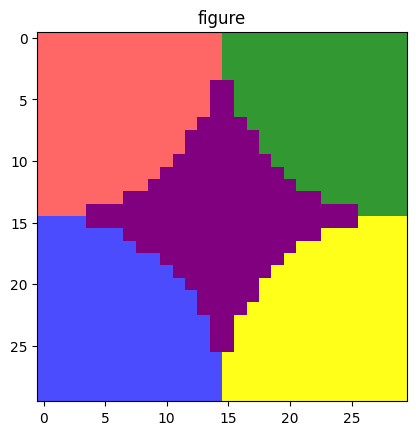

In [63]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [64]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make Vs based on a task covariance + parcel covariance

In [97]:
R = np.diag([1, 1, 1, 1, 1])
n = 50

# Sim 1 : tasks IID, predicition none of the metrics would be useful

In [ ]:
corr_var_cos = []
corr_var_mc_cos = []
corr_log_det_cos = []
corr_log_det_mc_cos = []
corr_inv_trace_cos = []
corr_inv_trace_mc_cos = []

Vs = []

for i in range(n):
    if i % 10 == 0:
        print(i)
    # make G and Vs
    G = np.diag([1, 1, 1, 1, 1])
    VLib= sim.find_best_V(G= G, R= R,num_iter=10)

    # make data and G_lib
    Y_true = VLib @ np.array(U_true_5[0])
    G_lib = Y_true @ Y_true.T
    G_lib = np.array(G_lib)

    vtest = VLib
    ytest = Y_true

    # tried different values
    noise = 0.4

    # this will sample task batteries of 3 tasks and 3 unique tasks
    D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D,Y_true, VLib, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
    
    
    corr = np.corrcoef(D_ev['variance'], D_ev['cos'])[0,1]
    corr_var_cos.append(corr)
    corr = np.corrcoef(D_ev['variance_mc'], D_ev['cos'])[0,1]
    corr_var_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det'], D_ev['cos'])[0,1]
    corr_log_det_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det_mc'], D_ev['cos'])[0,1]
    corr_log_det_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace'], D_ev['cos'])[0,1]
    corr_inv_trace_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace_mc'], D_ev['cos'])[0,1]
    corr_inv_trace_mc_cos.append(corr)



    


print('corr_var_cos',np.nanmean(corr_var_cos))
print('corr_var_mc_cos',np.nanmean(corr_var_mc_cos))
print('corr_log_det_cos',np.nanmean(corr_log_det_cos))
print('corr_log_det_mc_cos',np.nanmean(corr_log_det_mc_cos))
print('corr_inv_trace_cos',np.nanmean(corr_inv_trace_cos))
print('corr_inv_trace_mc_cos',np.nanmean(corr_inv_trace_mc_cos))





0
10
20
30
40
corr_var_cos -0.04182491270188577
corr_var_mc_cos -0.00705922914456475
corr_log_det_cos -0.02772112256961558
corr_log_det_mc_cos 0.02973351137478741
corr_inv_trace_cos -0.03439494463106305
corr_inv_trace_mc_cos 0.01347231430424183


# Sim 2: no correaltions, differences in diagonal. Prediction: all metrics would be useful

In [100]:
corr_var_cos = []
corr_var_mc_cos = []
corr_log_det_cos = []
corr_log_det_mc_cos = []
corr_inv_trace_cos = []
corr_inv_trace_mc_cos = []

for i in range(n):
    if i % 10 == 0:
        print(i)
    # make G and Vs
    G = np.diag([0.9, 0.7, 0.2, 0.3, 0.5])
    VLib= sim.find_best_V(G= G, R= R,num_iter=10)

    # make data and G_lib
    Y_true = VLib @ np.array(U_true_5[0])
    G_lib = Y_true @ Y_true.T
    G_lib = np.array(G_lib)

    vtest = VLib
    ytest = Y_true

    # tried different values
    noise = 0.4

    # this will sample task batteries of 3 tasks and 3 unique tasks
    D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D,Y_true, VLib, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
    
    
    corr = np.corrcoef(D_ev['variance'], D_ev['cos'])[0,1]
    corr_var_cos.append(corr)
    corr = np.corrcoef(D_ev['variance_mc'], D_ev['cos'])[0,1]
    corr_var_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det'], D_ev['cos'])[0,1]
    corr_log_det_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det_mc'], D_ev['cos'])[0,1]
    corr_log_det_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace'], D_ev['cos'])[0,1]
    corr_inv_trace_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace_mc'], D_ev['cos'])[0,1]
    corr_inv_trace_mc_cos.append(corr)



    


print('corr_var_cos',np.nanmean(corr_var_cos))
print('corr_var_mc_cos',np.nanmean(corr_var_mc_cos))
print('corr_log_det_cos',np.nanmean(corr_log_det_cos))
print('corr_log_det_mc_cos',np.nanmean(corr_log_det_mc_cos))
print('corr_inv_trace_cos',np.nanmean(corr_inv_trace_cos))
print('corr_inv_trace_mc_cos',np.nanmean(corr_inv_trace_mc_cos))


0
10
20
30
40
corr_var_cos -0.6687570527671179
corr_var_mc_cos -0.6687570527671179
corr_log_det_cos -0.6450247703489492
corr_log_det_mc_cos -0.01208715760019566
corr_inv_trace_cos -0.5961063893289071
corr_inv_trace_mc_cos -0.08070436668072746


# Sim 3: constant diagonal, correlations on the off-diagonal. Prediction??

In [101]:
corr_var_cos = []
corr_var_mc_cos = []
corr_log_det_cos = []
corr_log_det_mc_cos = []
corr_inv_trace_cos = []
corr_inv_trace_mc_cos = []

for i in range(n):
    if i % 10 == 0:
        print(i)
    G = np.array([[1, 0.3, 0.2, 0.1 ,0.3],
                    [0.3, 1, 0.5, 0.4, 0.3],
                    [0.2, 0.5, 1, 0.1, 0.4],
                    [0.1, 0.4, 0.1, 1, 0.5],
                    [0.3, 0.3, 0.4, 0.5, 1]])
    VLib= sim.find_best_V(G= G, R= R,num_iter=10000)


    # make data and G_lib
    Y_true = VLib @ np.array(U_true_5[0])
    G_lib = Y_true @ Y_true.T
    G_lib = np.array(G_lib)

    vtest = VLib
    ytest = Y_true

    # tried different values
    noise = 0.4

    # this will sample task batteries of 3 tasks and 3 unique tasks
    D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D,Y_true, VLib, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
    
    
    corr = np.corrcoef(D_ev['variance'], D_ev['cos'])[0,1]
    corr_var_cos.append(corr)
    corr = np.corrcoef(D_ev['variance_mc'], D_ev['cos'])[0,1]
    corr_var_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det'], D_ev['cos'])[0,1]
    corr_log_det_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det_mc'], D_ev['cos'])[0,1]
    corr_log_det_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace'], D_ev['cos'])[0,1]
    corr_inv_trace_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace_mc'], D_ev['cos'])[0,1]
    corr_inv_trace_mc_cos.append(corr)



    


print('corr_var_cos',np.nanmean(corr_var_cos))
print('corr_var_mc_cos',np.nanmean(corr_var_mc_cos))
print('corr_log_det_cos',np.nanmean(corr_log_det_cos))
print('corr_log_det_mc_cos',np.nanmean(corr_log_det_mc_cos))
print('corr_inv_trace_cos',np.nanmean(corr_inv_trace_cos))
print('corr_inv_trace_mc_cos',np.nanmean(corr_inv_trace_mc_cos))


0
10
20
30
40
corr_var_cos -0.08900944281450208
corr_var_mc_cos -0.24708415745948067
corr_log_det_cos -0.24669042953758488
corr_log_det_mc_cos -0.012724928878458037
corr_inv_trace_cos -0.23659401881370434
corr_inv_trace_mc_cos -0.031202648435385463


# Sim 4: differences in both diagonal and off-diagonal. Prediction??

In [102]:
corr_var_cos = []
corr_var_mc_cos = []
corr_log_det_cos = []
corr_log_det_mc_cos = []
corr_inv_trace_cos = []
corr_inv_trace_mc_cos = []

for i in range(50):
    if i % 10 == 0:
        print(i)
    # make G and Vs
    G = np.array([[0.9, 0.45, 0.36, 0.41, 0.46],
                [0.45, 0.55, 0.4, 0.47, 0.45],
                [0.36, 0.4, 0.6, 0.35, 0.35],
                [0.41, 0.47, 0.35, 0.7, 0.45],
                [0.46, 0.45, 0.35, 0.45, 0.6]])
    VLib= sim.find_best_V(G= G, R= R,num_iter=10)

    # make data and G_lib
    Y_true = VLib @ np.array(U_true_5[0])
    G_lib = Y_true @ Y_true.T
    G_lib = np.array(G_lib)

    vtest = VLib
    ytest = Y_true

    # tried different values
    noise = 0.4

    # this will sample task batteries of 3 tasks and 3 unique tasks
    D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
    D_ev = ev.sim_evaluate_dataframe_multiregion(D,Y_true, VLib, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
    
    
    corr = np.corrcoef(D_ev['variance'], D_ev['cos'])[0,1]
    corr_var_cos.append(corr)
    corr = np.corrcoef(D_ev['variance_mc'], D_ev['cos'])[0,1]
    corr_var_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det'], D_ev['cos'])[0,1]
    corr_log_det_cos.append(corr)
    corr = np.corrcoef(D_ev['log_det_mc'], D_ev['cos'])[0,1]
    corr_log_det_mc_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace'], D_ev['cos'])[0,1]
    corr_inv_trace_cos.append(corr)
    corr = np.corrcoef(D_ev['inverse_trace_mc'], D_ev['cos'])[0,1]
    corr_inv_trace_mc_cos.append(corr)



    


print('corr_var_cos',np.nanmean(corr_var_cos))
print('corr_var_mc_cos',np.nanmean(corr_var_mc_cos))
print('corr_log_det_cos',np.nanmean(corr_log_det_cos))
print('corr_log_det_mc_cos',np.nanmean(corr_log_det_mc_cos))
print('corr_inv_trace_cos',np.nanmean(corr_inv_trace_cos))
print('corr_inv_trace_mc_cos',np.nanmean(corr_inv_trace_mc_cos))



0
10
20
30
40
corr_var_cos -0.3672708381608147
corr_var_mc_cos -0.4185787327326309
corr_log_det_cos -0.41960094542410187
corr_log_det_mc_cos -0.09471318056721355
corr_inv_trace_cos -0.4120922702774161
corr_inv_trace_mc_cos -0.20058710049162037
